# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

data = pd.read_csv("auto_dataset.csv")

print("Размер датасета:", data.shape)
display(data.head())
print("\nПропуски:")
display(data.isna().sum().to_frame("n_missing"))


Размер датасета: (1000, 10)


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000



Пропуски:


,n_missing
brand,0
model,0
vehicleType,0
gearbox,0
fuelType,0
notRepairedDamage,0
powerPS,0
kilometer,0
autoAgeMonths,0
price,0


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [17]:
target = "price"

X = data.drop(columns=[target]).copy()
y = data[target].astype(float).copy()

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=float)

print("Категориальные признаки:", categorical_cols)
print("Размер X после кодирования:", X.shape)
display(X.head())


Категориальные признаки: ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
Размер X после кодирования: (1000, 204)


,powerPS,kilometer,autoAgeMonths,brand_audi,brand_bmw,brand_chevrolet,brand_chrysler,brand_citroen,brand_dacia,brand_daewoo,...,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_benzin,fuelType_diesel,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein
0,75,150000,177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,69,90000,93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,102,150000,246,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,109,150000,140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,105,150000,136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


3. Разбейте датасет на train val test в отношении 8:1:1

In [18]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=1/9,
    random_state=RANDOM_STATE
)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)


numeric_cols = ["powerPS", "kilometer", "autoAgeMonths"]
scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


X_train_np = np.column_stack([np.ones(len(X_train)), X_train.to_numpy(dtype=float)])
X_val_np   = np.column_stack([np.ones(len(X_val)),   X_val.to_numpy(dtype=float)])
X_test_np  = np.column_stack([np.ones(len(X_test)),  X_test.to_numpy(dtype=float)])

y_train_np = y_train.to_numpy(dtype=float)
y_val_np   = y_val.to_numpy(dtype=float)
y_test_np  = y_test.to_numpy(dtype=float)

print("После добавления intercept:")
print("train:", X_train_np.shape)
print("val:  ", X_val_np.shape)
print("test: ", X_test_np.shape)


train: (800, 204) (800,)
val:   (100, 204) (100,)
test:  (100, 204) (100,)
После добавления intercept:
train: (800, 205)
val:   (100, 205)
test:  (100, 205)


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

VGD — constant
Лучший шаг: η = 0.1
Loss_train = 17895761.0975
Loss_val   = 21647885.0592
Loss_test  = 27899137.9189
R2_train   = 0.6988
R2_test    = 0.5206
Итерации   = 41


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,4.326496e+07,5.692342e+07,0.271850,0.273196,10000,False
1,0.00010,1.992790e+07,2.312626e+07,0.664613,0.704722,10000,False
2,0.00100,1.852492e+07,2.175743e+07,0.688225,0.722199,2401,False
3,0.01000,1.851870e+07,2.175397e+07,0.688330,0.722243,241,False
4,0.10000,1.789576e+07,2.164789e+07,0.698814,0.723598,41,False
5,1.00000,inf,inf,-inf,-inf,17,True


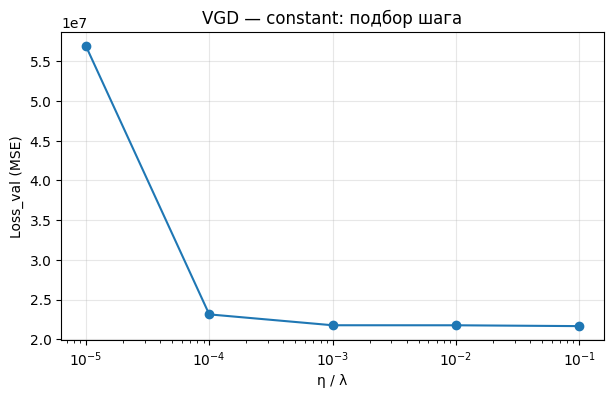

In [19]:
class LinearRegressionOptimizer:
    def __init__(
        self,
        method,
        step,
        schedule="constant",
        max_iter=10_000,
        grad_tol=0.05,
        eval_every=20,
        batch_size=32,
        alpha=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        s0=1.0,
        p=0.5,
        random_state=42
    ):
        self.method = method.lower()
        self.step = float(step)
        self.schedule = schedule
        self.max_iter = max_iter
        self.grad_tol = grad_tol
        self.eval_every = eval_every
        self.batch_size = batch_size

        self.alpha = alpha
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.s0 = s0
        self.p = p
        self.random_state = random_state

    def _learning_rate(self, k):
        if self.schedule == "constant":
            return self.step
        if self.schedule == "decay":

            return self.step * (self.s0 / (self.s0 + k)) ** self.p
        raise ValueError("schedule должен быть 'constant' или 'decay'")

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n, d = X.shape
        rng = np.random.default_rng(self.random_state)

        self.coef_ = np.zeros(d)
        self.coef_[0] = y.mean()

        self.history_ = []
        self.diverged_ = False

        initial_error = X @ self.coef_ - y
        initial_grad = (2 / n) * (X.T @ initial_error)
        initial_grad_norm = max(np.linalg.norm(initial_grad), 1e-12)

        velocity = np.zeros(d)
        m = np.zeros(d)
        v = np.zeros(d)

        if self.method == "sag":
            grad_memory = np.zeros((n, d))
            avg_grad = np.zeros(d)

        for k in range(self.max_iter):
            eta = self._learning_rate(k)

            if self.method == "vgd":
                error = X @ self.coef_ - y
                grad = (2 / n) * (X.T @ error)
                self.coef_ -= eta * grad

            elif self.method == "sgd":
                size = min(self.batch_size, n)
                idx = rng.choice(n, size=size, replace=False)
                X_batch = X[idx]
                y_batch = y[idx]

                error = X_batch @ self.coef_ - y_batch
                grad = (2 / size) * (X_batch.T @ error)
                self.coef_ -= eta * grad

            elif self.method == "sag":
                j = int(rng.integers(0, n))
                x_j = X[j]

                new_grad_j = 2 * (x_j @ self.coef_ - y[j]) * x_j
                avg_grad += (new_grad_j - grad_memory[j]) / n
                grad_memory[j] = new_grad_j

                self.coef_ -= eta * avg_grad

            elif self.method == "momentum":
                error = X @ self.coef_ - y
                grad = (2 / n) * (X.T @ error)

                velocity = self.alpha * velocity + eta * grad
                self.coef_ -= velocity

            elif self.method == "adam":
                error = X @ self.coef_ - y
                grad = (2 / n) * (X.T @ error)
                t = k + 1

                m = self.beta1 * m + (1 - self.beta1) * grad
                v = self.beta2 * v + (1 - self.beta2) * (grad ** 2)

                m_hat = m / (1 - self.beta1 ** t)
                v_hat = v / (1 - self.beta2 ** t)

                self.coef_ -= eta * m_hat / (np.sqrt(v_hat) + self.eps)

            else:
                raise ValueError("Неизвестный method")


            if (not np.all(np.isfinite(self.coef_))) or np.linalg.norm(self.coef_) > 1e15:
                self.diverged_ = True
                self.n_iter_ = k + 1
                return self


            if (k % self.eval_every == 0) or (k == self.max_iter - 1):
                pred = X @ self.coef_
                loss = np.mean((pred - y) ** 2)
                self.history_.append((k + 1, loss))

                if (not np.isfinite(loss)) or loss > 1e30:
                    self.diverged_ = True
                    self.n_iter_ = k + 1
                    return self

                full_grad = (2 / n) * (X.T @ (pred - y))


                if np.linalg.norm(full_grad) <= self.grad_tol * initial_grad_norm:
                    self.n_iter_ = k + 1
                    return self

        self.n_iter_ = self.max_iter
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_


def calculate_metrics(model, X, y):
    if getattr(model, "diverged_", False):
        return np.inf, -np.inf

    pred = model.predict(X)

    if not np.all(np.isfinite(pred)):
        return np.inf, -np.inf

    return mean_squared_error(y, pred), r2_score(y, pred)


lambda_grid = np.logspace(-5, 0, 6)

all_results = []
best_models = {}
search_tables = {}


def run_experiment(method, schedule, pretty_name):
    rows = []
    models = {}

    for step in lambda_grid:
        model = LinearRegressionOptimizer(
            method=method,
            step=step,
            schedule=schedule,
            random_state=RANDOM_STATE
        )
        model.fit(X_train_np, y_train_np)

        loss_train, r2_train = calculate_metrics(model, X_train_np, y_train_np)
        loss_val, r2_val = calculate_metrics(model, X_val_np, y_val_np)

        rows.append({
            "step": step,
            "Loss_train": loss_train,
            "Loss_val": loss_val,
            "R2_train": r2_train,
            "R2_val": r2_val,
            "iterations": model.n_iter_,
            "diverged": model.diverged_
        })

        models[step] = model

    search_df = pd.DataFrame(rows)

    finite = search_df[np.isfinite(search_df["Loss_val"])].copy()
    if finite.empty:
        raise RuntimeError(f"{pretty_name}: все значения шага привели к расходимости")

    best_idx = finite["Loss_val"].idxmin()
    best_row = search_df.loc[best_idx]

    best_step = float(best_row["step"])
    best_model = models[best_step]


    loss_test, r2_test = calculate_metrics(best_model, X_test_np, y_test_np)

    if schedule == "constant":
        step_repr = f"η = {best_step:g}"
    else:
        step_repr = f"η_k = {best_step:g}·(1/(1+k))^0.5"

    result = {
        "Метод": pretty_name,
        "Лучший шаг": step_repr,
        "step_value": best_step,
        "Loss_train": best_row["Loss_train"],
        "Loss_val": best_row["Loss_val"],
        "Loss_test": loss_test,
        "R2_train": best_row["R2_train"],
        "R2_test": r2_test,
        "Итерации": int(best_model.n_iter_)
    }

    all_results.append(result)
    best_models[pretty_name] = best_model
    search_tables[pretty_name] = search_df

    print(pretty_name)
    print(f"Лучший шаг: {step_repr}")
    print(f"Loss_train = {result['Loss_train']:.4f}")
    print(f"Loss_val   = {result['Loss_val']:.4f}")
    print(f"Loss_test  = {result['Loss_test']:.4f}")
    print(f"R2_train   = {result['R2_train']:.4f}")
    print(f"R2_test    = {result['R2_test']:.4f}")
    print(f"Итерации   = {result['Итерации']}")

    display(search_df)

    plot_df = search_df[np.isfinite(search_df["Loss_val"])]

    plt.figure(figsize=(7, 4))
    plt.plot(plot_df["step"], plot_df["Loss_val"], marker="o")
    plt.xscale("log")
    plt.xlabel("η / λ")
    plt.ylabel("Loss_val (MSE)")
    plt.title(f"{pretty_name}: подбор шага")
    plt.grid(True, alpha=0.3)
    plt.show()

    return result



vgd_const = run_experiment(
    method="vgd",
    schedule="constant",
    pretty_name="VGD — constant"
)


5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

VGD — TimeDecayLR
Лучший шаг: η_k = 0.1·(1/(1+k))^0.5
Loss_train = 18523795.5698
Loss_val   = 21753981.4605
Loss_test  = 28569472.3507
R2_train   = 0.6882
R2_test    = 0.5091
Итерации   = 161


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.900235e+07,7.829940e+07,0.006989,0.000266,10000,False
1,0.00010,5.546406e+07,7.353865e+07,0.066539,0.061052,10000,False
2,0.00100,3.401044e+07,4.402028e+07,0.427604,0.437945,10000,False
3,0.01000,1.877051e+07,2.187214e+07,0.684092,0.720734,10000,False
4,0.10000,1.852380e+07,2.175398e+07,0.688244,0.722243,161,False
5,1.00000,1.671318e+07,2.176153e+07,0.718717,0.722147,41,False


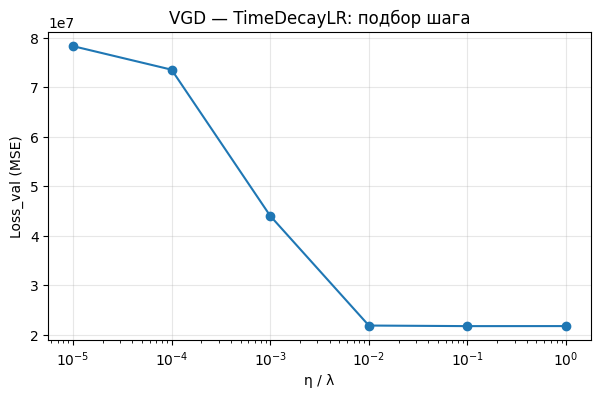

In [20]:
vgd_decay = run_experiment(
    method="vgd",
    schedule="decay",
    pretty_name="VGD — TimeDecayLR"
)


6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SGD — constant
Лучший шаг: η = 0.01
Loss_train = 18170096.5470
Loss_val   = 21667709.1300
Loss_test  = 28411435.1362
R2_train   = 0.6942
R2_test    = 0.5118
Итерации   = 321


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,4.319117e+07,5.681815e+07,0.273092,0.274540,10000,False
1,0.00010,1.989538e+07,2.308687e+07,0.665160,0.705225,10000,False
2,0.00100,1.845665e+07,2.178430e+07,0.689374,0.721856,2541,False
3,0.01000,1.817010e+07,2.166771e+07,0.694197,0.723345,321,False
4,0.10000,1.704566e+07,2.213006e+07,0.713121,0.717441,101,False
5,1.00000,inf,inf,-inf,-inf,17,True


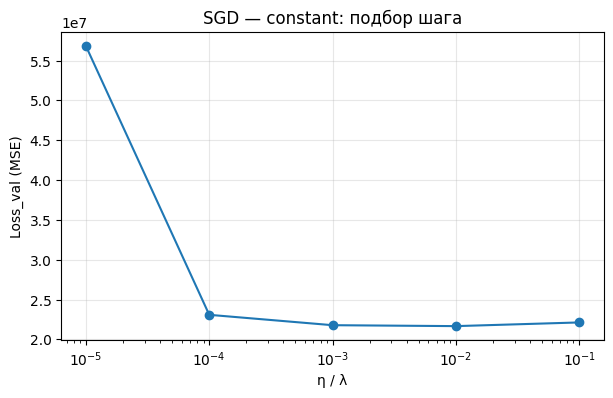

In [21]:
sgd_const = run_experiment(
    method="sgd",
    schedule="constant",
    pretty_name="SGD — constant"
)


7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SGD — TimeDecayLR
Лучший шаг: η_k = 0.1·(1/(1+k))^0.5
Loss_train = 18252744.0999
Loss_val   = 21854132.1021
Loss_test  = 28514733.3096
R2_train   = 0.6928
R2_test    = 0.5100
Итерации   = 281


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.899918e+07,7.829467e+07,0.007043,0.000326,10000,False
1,0.00010,5.543518e+07,7.349552e+07,0.067025,0.061602,10000,False
2,0.00100,3.390036e+07,4.384583e+07,0.429456,0.440172,10000,False
3,0.01000,1.877010e+07,2.185966e+07,0.684099,0.720894,10000,False
4,0.10000,1.825274e+07,2.185413e+07,0.692806,0.720964,281,False
5,1.00000,3.359568e+07,3.988587e+07,0.434584,0.490733,3901,False


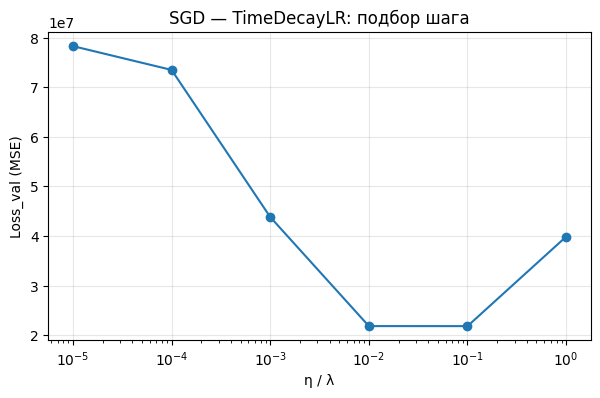

In [22]:
sgd_decay = run_experiment(
    method="sgd",
    schedule="decay",
    pretty_name="SGD — TimeDecayLR"
)


8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SAG — constant
Лучший шаг: η = 0.001
Loss_train = 18084047.0163
Loss_val   = 21956864.8297
Loss_test  = 27746317.6617
R2_train   = 0.6956
R2_test    = 0.5232
Итерации   = 4141


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,4.399294e+07,5.791825e+07,0.259598,0.260494,10000,False
1,0.00010,1.986670e+07,2.272422e+07,0.665643,0.709855,10000,False
2,0.00100,1.808405e+07,2.195686e+07,0.695645,0.719653,4141,False
3,0.01000,1.384659e+07,2.260704e+07,0.766962,0.711351,7661,False
4,0.10000,5.736471e+10,5.949968e+10,-964.449125,-758.697622,10000,False
5,1.00000,inf,inf,-inf,-inf,4787,True


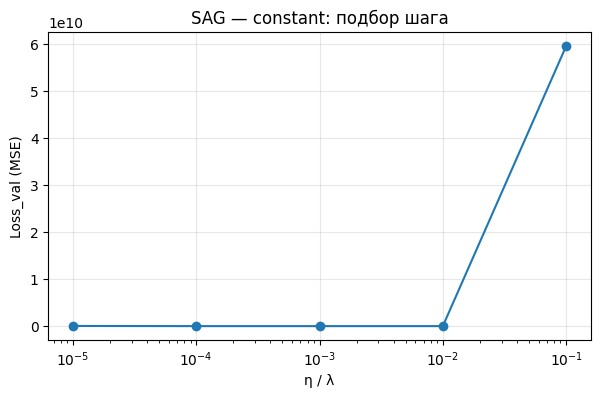

In [23]:
sag_const = run_experiment(
    method="sag",
    schedule="constant",
    pretty_name="SAG — constant"
)


9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SAG — TimeDecayLR
Лучший шаг: η_k = 0.01·(1/(1+k))^0.5
Loss_train = 19093786.7566
Loss_val   = 21931859.4539
Loss_test  = 29147262.8344
R2_train   = 0.6787
R2_test    = 0.4992
Итерации   = 10000


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.910081e+07,7.843133e+07,0.005332,-0.001419,10000,False
1,0.00010,5.635801e+07,7.474164e+07,0.051494,0.045692,10000,False
2,0.00100,3.741064e+07,4.879070e+07,0.370378,0.377036,10000,False
3,0.01000,1.909379e+07,2.193186e+07,0.678651,0.719972,10000,False
4,0.10000,1.842393e+07,2.203297e+07,0.689925,0.718681,1261,False
5,1.00000,1.357287e+07,2.333869e+07,0.771568,0.702009,5621,False


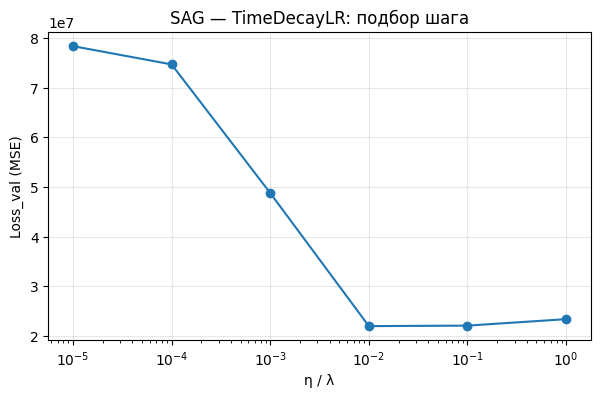

In [24]:
sag_decay = run_experiment(
    method="sag",
    schedule="decay",
    pretty_name="SAG — TimeDecayLR"
)


10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum — constant
Лучший шаг: η = 0.01
Loss_train = 17621044.8976
Loss_val   = 21449006.2864
Loss_test  = 27878881.9845
R2_train   = 0.7034
R2_test    = 0.5210
Итерации   = 61


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,1.992726e+07,2.312268e+07,0.664624,0.704767,10000,False
1,0.00010,1.852652e+07,2.175564e+07,0.688198,0.722222,2401,False
2,0.00100,1.853552e+07,2.174166e+07,0.688047,0.722400,241,False
3,0.01000,1.762104e+07,2.144901e+07,0.703438,0.726137,61,False
4,0.10000,1.504664e+07,2.187682e+07,0.746765,0.720675,41,False
5,1.00000,inf,inf,-inf,-inf,20,True


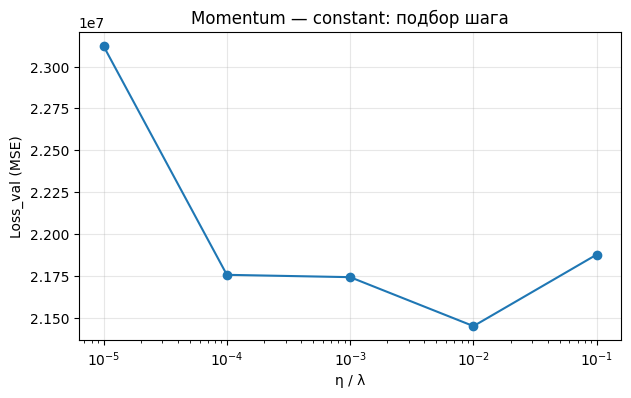

In [25]:
momentum_const = run_experiment(
    method="momentum",
    schedule="constant",
    pretty_name="Momentum — constant"
)


11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum — TimeDecayLR
Лучший шаг: η_k = 0.01·(1/(1+k))^0.5
Loss_train = 18506047.9614
Loss_val   = 21725345.7573
Loss_test  = 28544856.6496
R2_train   = 0.6885
R2_test    = 0.5095
Итерации   = 161


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.546537e+07,7.354042e+07,0.066517,0.061029,10000,False
1,0.00010,3.400294e+07,4.400942e+07,0.427730,0.438083,10000,False
2,0.00100,1.876940e+07,2.186919e+07,0.684111,0.720772,10000,False
3,0.01000,1.850605e+07,2.172535e+07,0.688543,0.722609,161,False
4,0.10000,1.624830e+07,2.195558e+07,0.726541,0.719669,81,False
5,1.00000,1.251060e+07,2.334287e+07,0.789446,0.701956,81,False


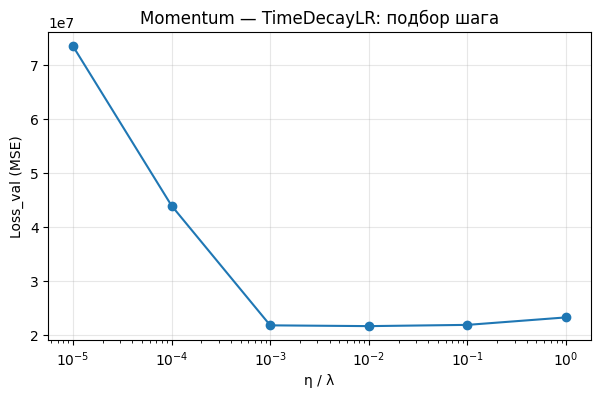

In [26]:
momentum_decay = run_experiment(
    method="momentum",
    schedule="decay",
    pretty_name="Momentum — TimeDecayLR"
)


12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Adam — constant
Лучший шаг: η = 1
Loss_train = 13229817.4754
Loss_val   = 23743176.3025
Loss_test  = 25423832.0359
R2_train   = 0.7773
R2_test    = 0.5632
Итерации   = 4461


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.941312e+07,7.885121e+07,0.000076,-0.006780,10000,False
1,0.00010,5.937243e+07,7.880152e+07,0.000761,-0.006145,10000,False
2,0.00100,5.896703e+07,7.830621e+07,0.007584,0.000179,10000,False
3,0.01000,5.506155e+07,7.351457e+07,0.073313,0.061359,10000,False
4,0.10000,2.880394e+07,4.116674e+07,0.515229,0.474379,10000,False
5,1.00000,1.322982e+07,2.374318e+07,0.777342,0.696845,4461,False


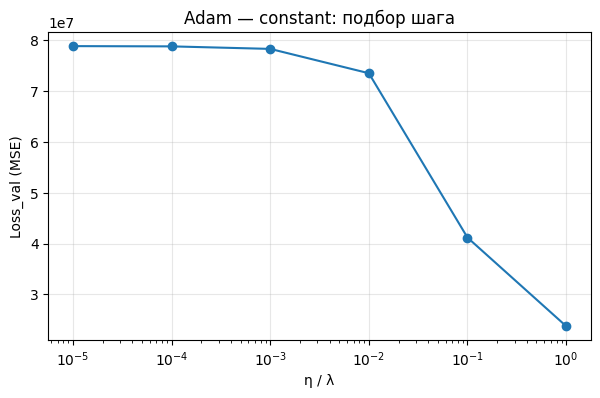

In [27]:
adam_const = run_experiment(
    method="adam",
    schedule="constant",
    pretty_name="Adam — constant"
)


13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Adam — TimeDecayLR
Лучший шаг: η_k = 1·(1/(1+k))^0.5
Loss_train = 51073568.4808
Loss_val   = 68584319.8028
Loss_test  = 51582059.8674
R2_train   = 0.1404
R2_test    = 0.1137
Итерации   = 10000


,step,Loss_train,Loss_val,R2_train,R2_val,iterations,diverged
0,0.00001,5.941756e+07,7.885662e+07,0.000002,-0.006849,10000,False
1,0.00010,5.941675e+07,7.885564e+07,0.000015,-0.006836,10000,False
2,0.00100,5.940867e+07,7.884577e+07,0.000151,-0.006710,10000,False
3,0.01000,5.932791e+07,7.874715e+07,0.001510,-0.005451,10000,False
4,0.10000,5.852610e+07,7.776712e+07,0.015005,0.007062,10000,False
5,1.00000,5.107357e+07,6.858432e+07,0.140431,0.124309,10000,False


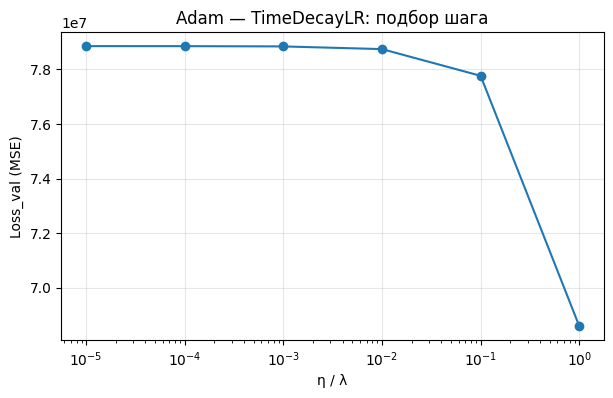

In [28]:
adam_decay = run_experiment(
    method="adam",
    schedule="decay",
    pretty_name="Adam — TimeDecayLR"
)


14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

,Метод,Лучший шаг,Loss_train,Loss_test,R2_train,R2_test,Итерации
0,Adam — constant,η = 1,"13,229,817.48","25,423,832.04",0.7773,0.5632,4461
1,SAG — constant,η = 0.001,"18,084,047.02","27,746,317.66",0.6956,0.5232,4141
2,Momentum — constant,η = 0.01,"17,621,044.90","27,878,881.98",0.7034,0.5210,61
3,VGD — constant,η = 0.1,"17,895,761.10","27,899,137.92",0.6988,0.5206,41
4,SGD — constant,η = 0.01,"18,170,096.55","28,411,435.14",0.6942,0.5118,321
5,SGD — TimeDecayLR,η_k = 0.1·(1/(1+k))^0.5,"18,252,744.10","28,514,733.31",0.6928,0.5100,281
6,Momentum — TimeDecayLR,η_k = 0.01·(1/(1+k))^0.5,"18,506,047.96","28,544,856.65",0.6885,0.5095,161
7,VGD — TimeDecayLR,η_k = 0.1·(1/(1+k))^0.5,"18,523,795.57","28,569,472.35",0.6882,0.5091,161
8,SAG — TimeDecayLR,η_k = 0.01·(1/(1+k))^0.5,"19,093,786.76","29,147,262.83",0.6787,0.4992,10000
9,Adam — TimeDecayLR,η_k = 1·(1/(1+k))^0.5,"51,073,568.48","51,582,059.87",0.1404,0.1137,10000


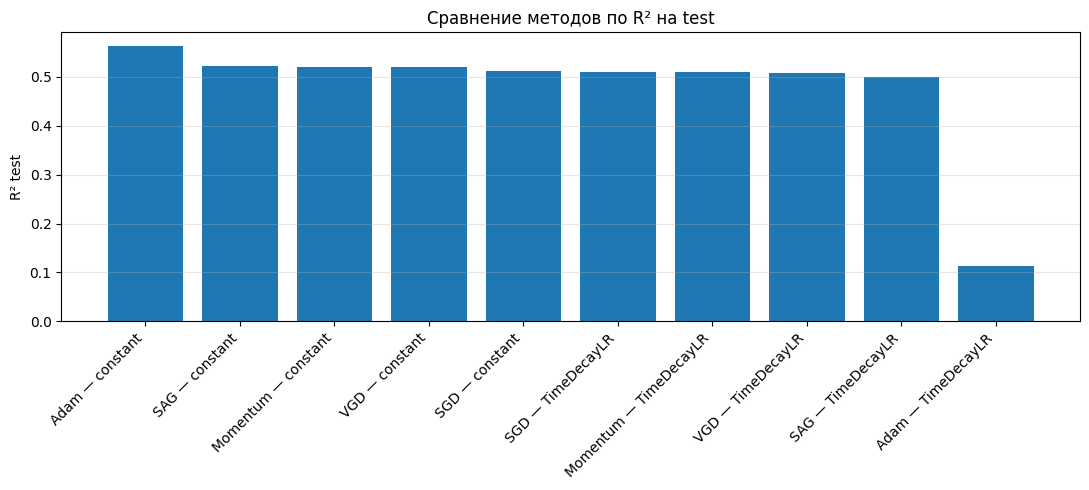

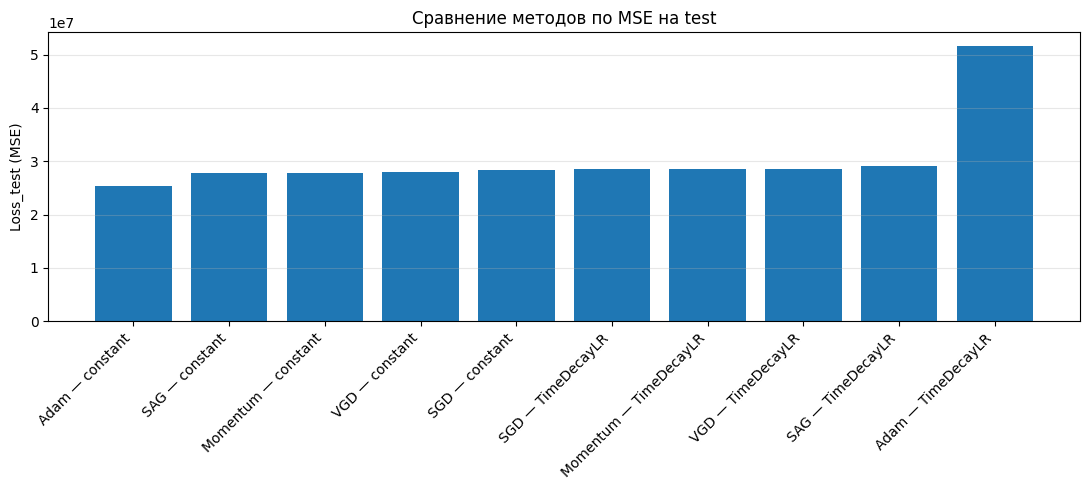

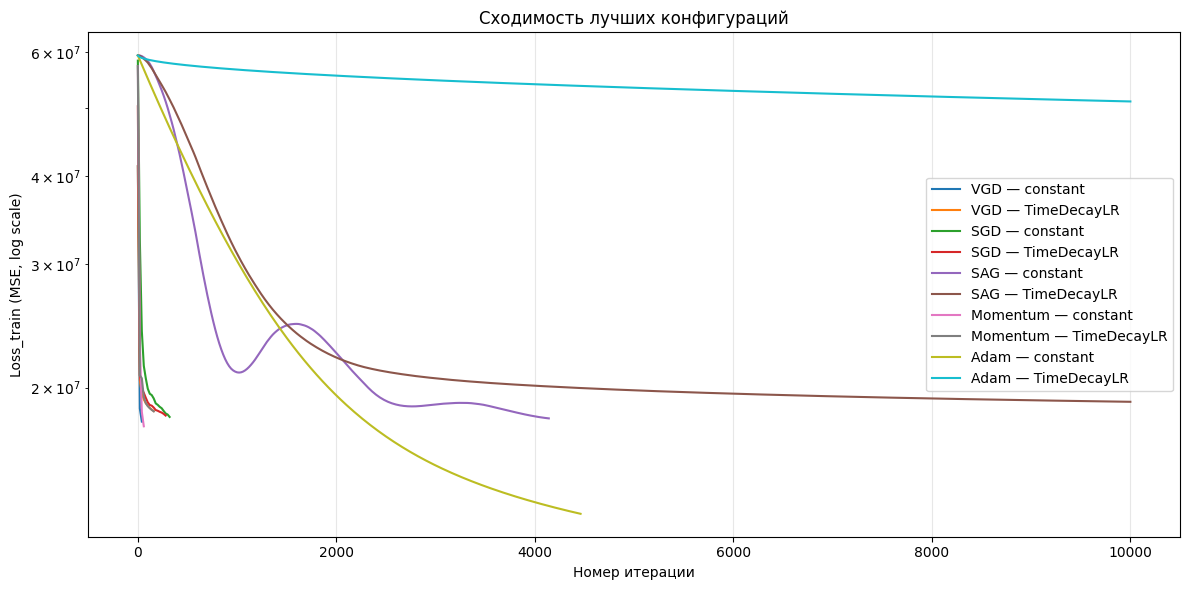

In [29]:
summary = pd.DataFrame(all_results)[[
    "Метод",
    "Лучший шаг",
    "Loss_train",
    "Loss_test",
    "R2_train",
    "R2_test",
    "Итерации"
]].copy()

summary = summary.sort_values("Loss_test").reset_index(drop=True)

display(
    summary.style.format({
        "Loss_train": "{:,.2f}",
        "Loss_test": "{:,.2f}",
        "R2_train": "{:.4f}",
        "R2_test": "{:.4f}"
    })
)


plt.figure(figsize=(11, 5))
plt.bar(summary["Метод"], summary["R2_test"])
plt.ylabel("R² test")
plt.title("Сравнение методов по R² на test")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 5))
plt.bar(summary["Метод"], summary["Loss_test"])
plt.ylabel("Loss_test (MSE)")
plt.title("Сравнение методов по MSE на test")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

for name, model in best_models.items():
    hist = np.asarray(model.history_, dtype=float)
    if len(hist) > 0:
        plt.plot(hist[:, 0], hist[:, 1], label=name)

plt.yscale("log")
plt.xlabel("Номер итерации")
plt.ylabel("Loss_train (MSE, log scale)")
plt.title("Сходимость лучших конфигураций")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

In [30]:
best = summary.loc[summary["Loss_test"].idxmin()]

print("ЛУЧШАЯ КОНФИГУРАЦИЯ НА TEST")
print("-" * 50)
print("Метод:       ", best["Метод"])
print("Лучший шаг:  ", best["Лучший шаг"])
print(f"Loss_train:   {best['Loss_train']:,.2f}")
print(f"Loss_test:    {best['Loss_test']:,.2f}")
print(f"R2_train:     {best['R2_train']:.4f}")
print(f"R2_test:      {best['R2_test']:.4f}")
print(f"Итерации:     {int(best['Итерации'])}")

print("""
1) Почему выбираем этот вариант?
Прогнав все 5 методов с разными шагами, нашли локальный лучший шаг по валидации для каждого метода, а потом сравнили методы с лучшими шагами. В 14 блоке видно, что оптимальнее всего использовать Адам с шагом 1, т.к. у него минимальный лосс на тестовой выборке и самый высокий р2тест, следовательно, он лучше будет предсказывать, но его минус, что ему нужно побольше итераций 4461, но это не страшно ибо мы ищем не самую быструю, а самую точную.

2) Простыми словами про R²_train и R²_test:
R²_train - число, показывающее насколько хорошо модель работает на данных, на которых она училась.
R²_test - число, показывающее насколько хорошо модель работает на новых для нее данных.
Логично, что чем оба параметра ближе к 1, тем лучше. Обобщая, это насколько использование модели будет лучше, чем использование средних значений выборки, только посчитанное на трейне и тесте, в нашем случае.
Если р2 у нас отрицательный, то получается, что лосс модели больше лосса по среднему, отсюда и получается минус, ибо 1 - (отношение лоссов > 1) - отрицательно. Значит, что диапазон ошибки предсказания от ошибки разницы со средним больше, что ОЧЕНЬ ОЧЕНЬ ПЛОХО.

3) Зачем нужны оба значения?
Если модель переобучилась и запомнила данные, то р2трейн будет высоким, без р2тест мы будем думать, что это модель крутая получилась, а с р2тест сможем определить: реально крутая или переобучилась. Очевидно, почему надо вычислять и то, и то: чтобы оценить обучение, ну и понять нужна ли нам вообще модель или легче среднее просто использовать)
""")


ЛУЧШАЯ КОНФИГУРАЦИЯ НА TEST
--------------------------------------------------
Метод:        Adam — constant
Лучший шаг:   η = 1
Loss_train:   13,229,817.48
Loss_test:    25,423,832.04
R2_train:     0.7773
R2_test:      0.5632
Итерации:     4461

1) Почему выбираем этот вариант?
Прогнав все 5 методов с разными шагами, нашли локальный лучший шаг по валидации для каждого метода, а потом сравнили методы с лучшими шагами. В 14 блоке видно, что оптимальнее всего использовать Адам с шагом 1, т.к. у него минимальный лосс на тестовой выборке и самый высокий р2тест, следовательно, он лучше будет предсказывать, но его минус, что ему нужно побольше итераций 4461, но это не страшно ибо мы ищем не самую быструю, а самую точную.

2) Простыми словами про R²_train и R²_test:
R²_train - число, показывающее насколько хорошо модель работает на данных, на которых она училась.
R²_test - число, показывающее насколько хорошо модель работает на новых для нее данных.
Логично, что чем оба параметра ближе к 1, т